# Predicting heart disease using machine learning
## 1. Problem Definition

In a statement, 
> Given clinical parameters about a patient, can we predict whether or not they have heart disease?

## 2. Data

The original dat acame from the Clevland data from the UCI Machine Learning Repository. https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

## 3. Evaluation

> If we can reach 95% accuracy at predicting wether or not a patient has heart disease during the proof of concept, we'll pursue the project.

## 4. Features
This is where you'll get different information about each of the features in your data.

Heart Disease Dataset Data Dictionary
| Column | Description | Values / Key |
| :--- | :--- | :--- |
| **age** | Age of patient | Years |
| **sex** | Gender | `1` = Male, `0` = Female |
| **cp** | Chest pain type | `0` = Typical Angina<br>`1` = Atypical Angina<br>`2` = Non-anginal Pain<br>`3` = Asymptomatic |
| **trestbps** | Resting blood pressure | mm Hg (Concern: >130–140) |
| **chol** | Serum cholesterol | mg/dL (Concern: >200) |
| **fbs** | Fasting blood sugar > 120 mg/dL | `1` = True, `0` = False (Diabetes: >126) |
| **restecg** | Resting ECG results | `0` = Normal<br>`1` = ST-T wave abnormality<br>`2` = Left ventricular hypertrophy |
| **thalach** | Max heart rate achieved | Beats per minute |
| **exang** | Exercise-induced angina | `1` = Yes, `0` = No |
| **oldpeak** | ST depression from exercise | Numeric stress level |
| **slope** | Peak exercise ST segment slope | `0` = Upsloping<br>`1` = Flat<br>`2` = Downsloping |
| **ca** | Major vessels colored by fluoroscopy | `0` to `3` |
| **thal** | Thallium stress result | `1` or `3` = Normal<br>`6` = Fixed defect<br>`7` = Reversible defect |
| **target** | Heart disease diagnosis | `1` = Yes, `0` = No |

## Preparing the tools

In [1]:
# Regular EDA and plotting liblaries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

sns.set_style('whitegrid')

## Load Data

In [2]:
df = pd.read_csv('../data/heart-disease.csv')
df.shape

(303, 14)

## Data Understanding

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


# 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.shape

(303, 14)

In [8]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

## Exploratory Data Analysis

In [9]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [12]:
# Compare target column with sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


In [13]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


Text(0.5, 0, '1 = disease, 0 = no disease')

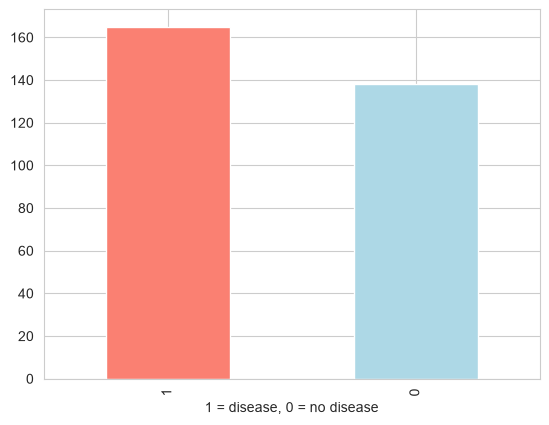

In [14]:
df['target'].value_counts().plot(kind='bar', color=['salmon', 'lightblue']);
plt.xlabel('1 = disease, 0 = no disease')

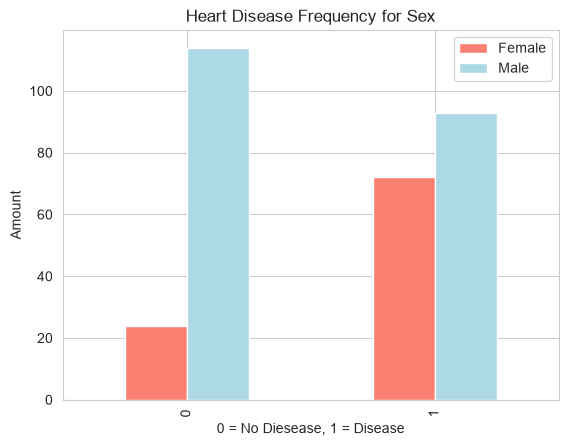

In [15]:
pd.crosstab(df.target, df.sex).plot(kind='bar', color=['salmon', 'lightblue'])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('0 = No Diesease, 1 = Disease')
plt.ylabel('Amount')
plt.legend(['Female', 'Male']);

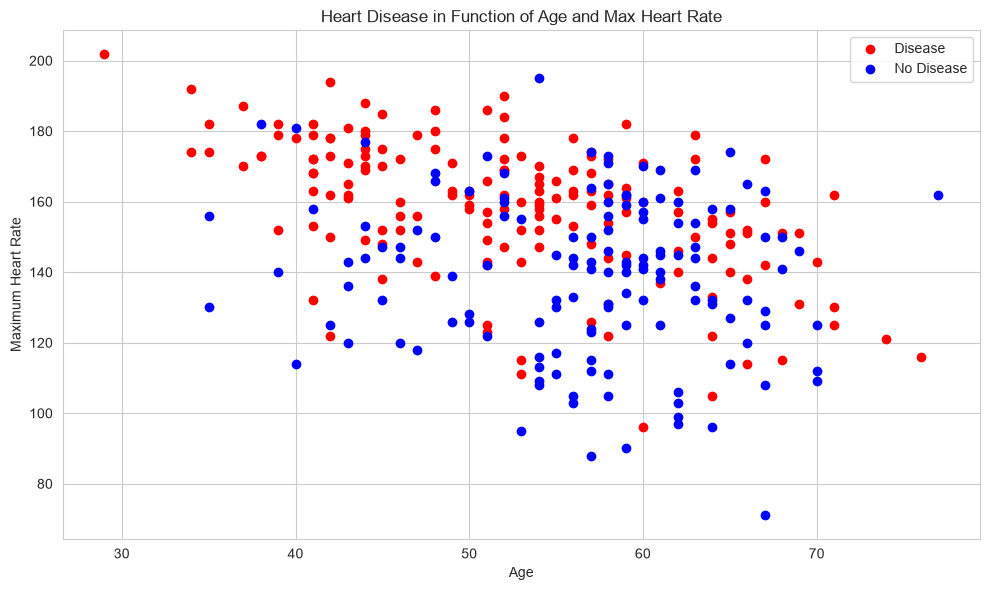

In [16]:
# age vs maximum heart rate
plt.figure(figsize=(10, 6))
plt.scatter(df.age[df.target==1], df.thalach[df.target==1], color='red')
plt.scatter(df.age[df.target==0], df.thalach[df.target==0], color='blue')
plt.title('Heart Disease in Function of Age and Max Heart Rate')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.legend(['Disease', 'No Disease'])
plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='Count'>

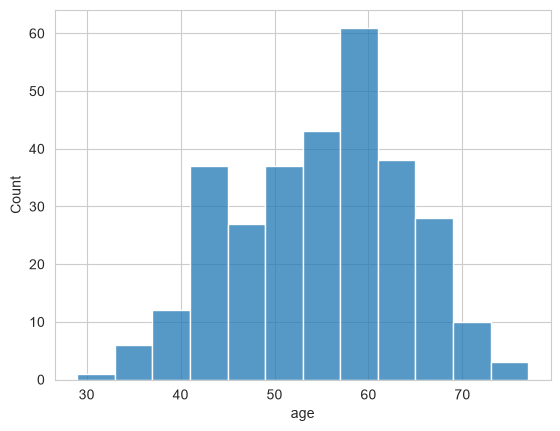

In [17]:
# check the distribution of the age column with a histogram
sns.histplot(df['age'])

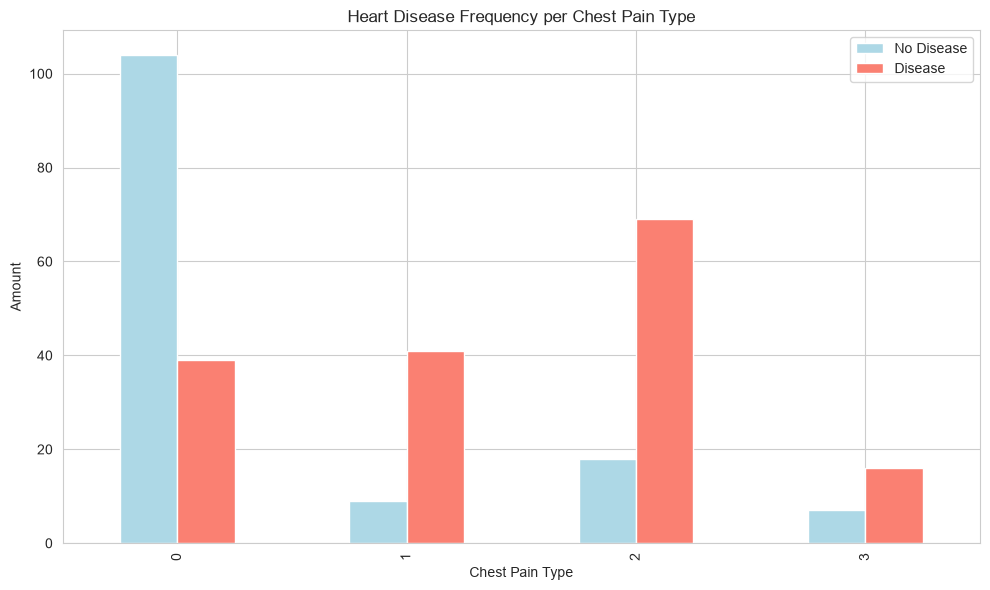

In [18]:
# Heart Disease Frequency per Chest Pain Type
# cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
pd.crosstab(df.cp, df.target).plot(kind='bar', figsize=(10, 6), color=['lightblue', 'salmon'])
plt.title('Heart Disease Frequency per Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Amount')
plt.legend(['No Disease', 'Disease'])
plt.tight_layout()

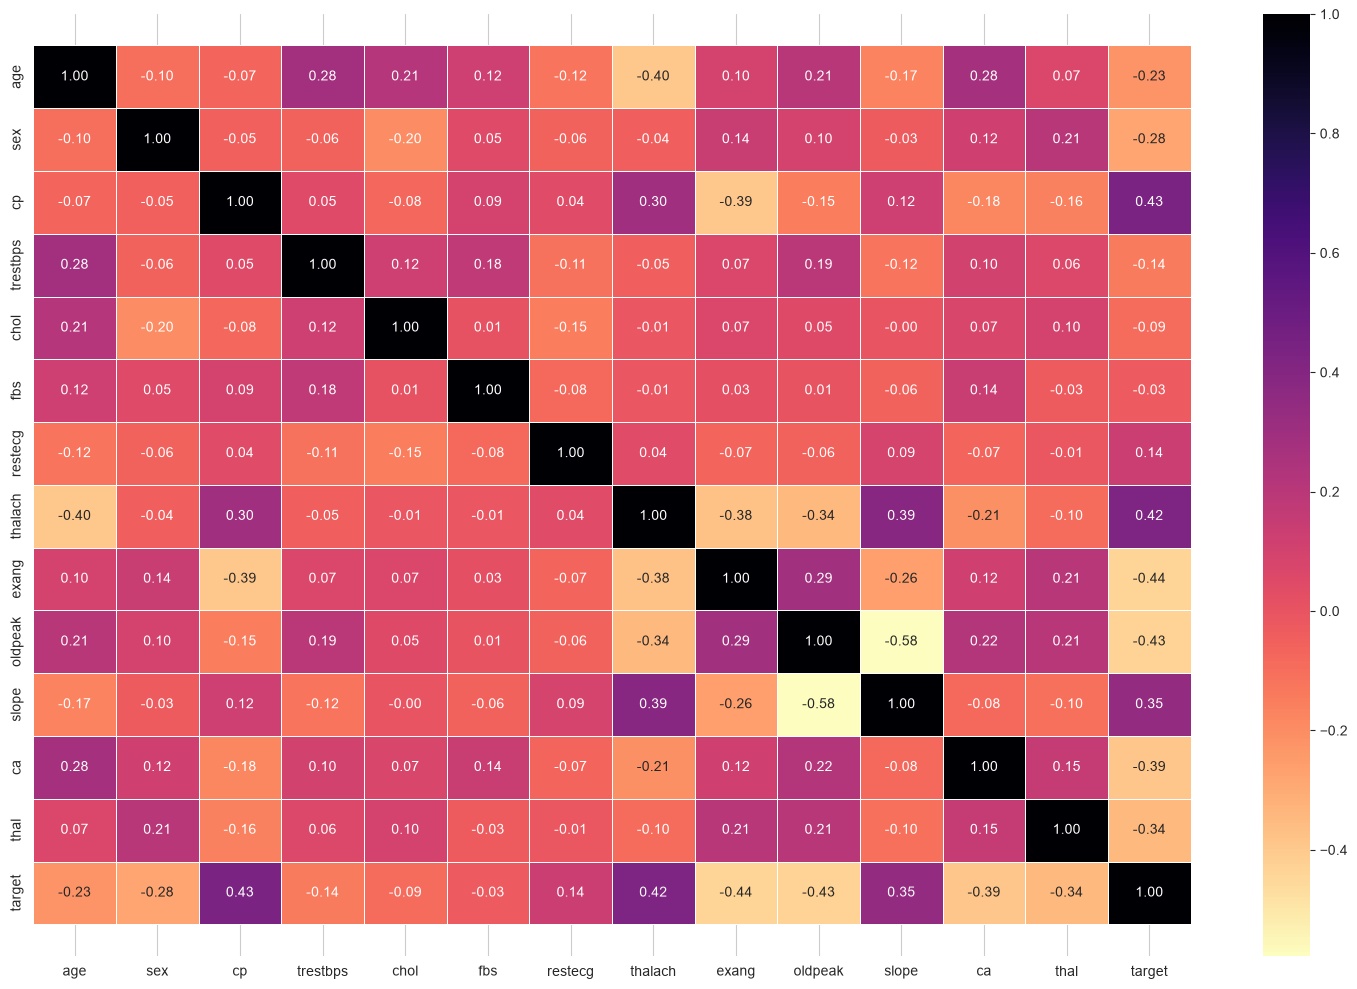

In [19]:
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(df.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='magma_r')
bot, top = ax.get_ylim()
ax.set_ylim(bot+0.5, top-0.5)
plt.tight_layout()

# Data Preprocessing

In [20]:
# Splitting data
X = df.drop('target', axis=1)
y = df['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Selection & Training

In [21]:
models = {'Logistic Regression': LogisticRegression(),
          'KNN Classifier': KNeighborsClassifier(),
          'Random Forest Classifier': RandomForestClassifier()}

In [22]:
def fit_and_score(models, X_train, X_test, y_train, y_test):
    model_scores = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        model_scores[model_name] = model.score(X_test, y_test)
    return model_scores

In [ ]:
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)
model_scores

d:\Development\Machine Learning\env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

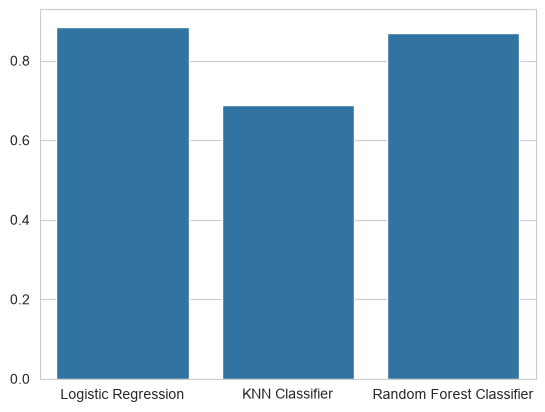

In [ ]:
model_scores_df = pd.DataFrame(model_scores, index=['Accuracy'])
sns.barplot(model_scores)